# Лабораторная работа №1

## Тема: Геометрический и программный методы решения задачи линейного программирования

> В этой работе используются два понятных инструмента: графический разбор на плоскости и решение в Python.
> В этой ЛР не используем симплекс-таблицы: фокус на геометрии, формах записи задачи, Лагранже/ККТ и проверке в Python.

### Как читать эту работу, если вы начинаете с нуля

- $x_1$, $x_2$ — это просто числа, которые нужно найти (сколько выпускать продукции каждого типа).
- Ограничение — это правило вида «нельзя превысить лимит ресурса».
- Целевая функция — это формула, которая показывает, что мы улучшаем (здесь: прибыль).
- Допустимая область — это все варианты плана, которые не нарушают ни одного ограничения.


## 1. Цель работы

Освоить базовый цикл решения задачи линейного программирования на примере одной и той же модели двумя способами:

1. Геометрически (вручную, на плоскости).
2. Математически и программно (через `scipy.optimize.linprog`).

## 2. Формируемые умения и навыки

После выполнения работы вы сможете:

1. Переводить текстовую производственную ситуацию в математическую модель линейного программирования.
2. Объяснять смысл переменных решения, целевой функции и ограничений простыми словами.
3. Строить граничные прямые и выбирать нужные полуплоскости.
4. Находить допустимую область и её угловые точки.
5. Вычислять значение целевой функции в вершинах и выбирать оптимум.
6. Выполнять переход от задачи максимизации к задаче минимизации.
7. Приводить задачу к классическому каноническому виду (то есть превращать неравенства в равенства с помощью добавочных переменных).
8. Представлять модель в формате $c$, `A_ub`, `b_ub`, `bounds` для Python.
9. Запускать решение через `linprog(method="highs")` и интерпретировать результат.


## 3. Теоретический минимум (подробно, для начинающих)

> Как работать с этим разделом: читайте по шагам, после каждой формулы проверяйте смысл обозначений.
> Если встретился новый термин, сразу используйте объяснение под ним и не переходите дальше, пока смысл не стал понятен.

### 3.1. Что такое линейное программирование

**Линейное программирование (ЛП)** — это раздел оптимизации, где нужно найти наилучшее значение целевой функции при линейных ограничениях.

Общий вид задачи:

$$
\max\; z = c_1x_1 + c_2x_2 + \dots + c_nx_n
$$

Здесь $x_i$ означает управляемые переменные (что мы выбираем); $c_i$ означает вклад каждой переменной в целевой показатель; $z$ означает итоговый показатель (например, прибыль).

Ограничения обычно записываются как:

$$
a_{11}x_1 + a_{12}x_2 + \dots + a_{1n}x_n \le b_1
$$

$$
a_{21}x_1 + a_{22}x_2 + \dots + a_{2n}x_n \le b_2
$$

$$
\vdots
$$

$$
x_i \ge 0
$$

Здесь $a_{ij}$ означает расход ресурса $i$ на единицу решения $j$; $b_i$ означает доступный запас ресурса $i$; условие $x_i \ge 0$ означает, что отрицательные объёмы выпуска недопустимы.

### 3.2. Что такое переменные решения

**Переменные решения** — это числа, которые мы подбираем. В производственной задаче это обычно объёмы выпуска.

Если переменная $x_1$ — количество изделий типа A, а $x_2$ — количество изделий типа B, то именно значения $x_1$ и $x_2$ мы ищем, чтобы получить лучший результат.

### 3.3. Что такое целевая функция

**Целевая функция** — это формула, которая выражает, что именно мы хотим оптимизировать (максимизировать прибыль, минимизировать затраты и т.д.).

В этой лабораторной:

$$
\max z = 5x_1 + 4x_2
$$

Здесь $x_1$ означает количество изделий A; $x_2$ означает количество изделий B; коэффициент $5$ означает прибыль с одной единицы A; коэффициент $4$ означает прибыль с одной единицы B; $z$ означает общую прибыль.

### 3.4. Что такое ограничения

**Ограничения** описывают реальные лимиты: ресурсы, время, мощности.

В нашей задаче:

$$
2x_1 + x_2 \le 10
$$

Здесь $2$ означает, что изделие A тратит 2 единицы первого ресурса; $1$ перед $x_2$ означает, что изделие B тратит 1 единицу первого ресурса; $10$ означает общий запас первого ресурса; знак $\le$ означает «не больше доступного запаса».

$$
x_1 + 2x_2 \le 8
$$

Здесь $1$ перед $x_1$ означает расход второго ресурса на A; $2$ перед $x_2$ означает расход второго ресурса на B; $8$ означает общий запас второго ресурса; знак $\le$ снова означает ограничение сверху по ресурсу.

$$
x_1 \ge 0,\quad x_2 \ge 0
$$

Здесь условия неотрицательности означают, что нельзя выпускать «минус 3 изделия»; объёмы выпуска могут быть только нулевыми или положительными.

### 3.5. Что такое допустимая область

**Допустимая область** — это все точки $(x_1, x_2)$, которые одновременно удовлетворяют всем ограничениям.

Если точка нарушает хотя бы одно ограничение, она недопустима. Если выполняет все, она допустима.

### 3.6. Что такое оптимум

**Оптимум** — это лучшая допустимая точка по целевой функции.

Для задачи максимизации оптимум — точка, где $z$ максимально возможна среди всех допустимых точек.

### 3.7. Почему в двумерном случае можно решать геометрически

Когда переменных две ($x_1$ и $x_2$), каждое линейное ограничение задаёт полуплоскость на координатной плоскости. Пересечение таких полуплоскостей образует многоугольник (или незамкнутую область). Это можно построить вручную и проанализировать визуально.

### 3.8. Почему оптимум ищется по вершинам допустимой области

Для линейной целевой функции на выпуклой (без вогнутых углов) многоугольной допустимой области максимум и минимум достигаются в угловых точках (вершинах).

Практически это значит: достаточно найти вершины допустимой области, вычислить целевую функцию в каждой вершине и выбрать лучшую.

### 3.9. Как не перепутать обозначения в этой ЛР

1. Геометрический метод:
- переменные решения $x_1, x_2$;
- целевая функция $z$;
- ограничения как прямые и полуплоскости.

2. Формы записи задачи:
- векторно-матрично: $c, A, b$;
- канонизация через добавочные переменные: $s_1, s_2, \dots$.

3. Лагранж/ККТ:
- множители $\lambda$ (для ресурсных ограничений) и $\nu$ (для ограничений неотрицательности $x\ge0$);
- условия допустимости, стационарности и комплементарной нежёсткости.

4. Python (`linprog`):
- входы: `c`, `A_ub`, `b_ub`, `bounds`;
- выходы: `res.x`, `res.fun`, `res.success`.

Важно: симплекс-таблицы, пивот-обозначения и шаги симплекс-алгоритма в этой ЛР не рассматриваются.

### 3.10. Метод функции Лагранжа (когда применим в ЛП)

Для ограничений-неравенств в линейном программировании используют Лагранжев подход в форме условий ККТ.

Идея: добавляем ограничения в целевую функцию через множители и получаем систему условий оптимальности.

Для модели

$$
\max c^{T} x,\quad Ax\le b,\quad x\ge0
$$

лагранжиан записывают как

$$
\mathcal{L}(x,\lambda,\nu)=c^{T} x + \lambda^{T}(b-Ax) + \nu^{T}x,
$$

$$
\lambda\ge0,\; \nu\ge0.
$$

ККТ для ЛП включают:

1. прямую допустимость: $Ax\le b$, $x\ge0$;
2. двойственную допустимость: $A^{T}\lambda-\nu=c$, $\lambda\ge0$, $\nu\ge0$;
3. комплементарную нежёсткость: $\lambda_i(b_i-(Ax)_i)=0$, $\nu_jx_j=0$.

Практический смысл:
- множители $\lambda_i$ интерпретируются как теневые цены ресурсов;
- этот же аппарат математически связывает прямую и двойственную задачи.
В обозначениях двойственной задачи часто используют $y$; в этой ЛР для ККТ используем эквивалентное обозначение $y \equiv \lambda$.

### 3.11. Как строить двойственную задачу по коэффициентам (без путаницы)

Для формы

$$
\max c^{T} x,\quad Ax\le b,\quad x\ge0
$$

правило такое:

1. Каждое ограничение прямой задачи $\rightarrow$ одна переменная $y_i$ в двойственной.
2. Каждая переменная $x_j$ в прямой $\rightarrow$ одно ограничение в двойственной.
3. Правая часть $b$ прямой становится коэффициентами цели двойственной.
4. Коэффициенты цели $c$ прямой становятся правыми частями ограничений двойственной.
5. Матрица коэффициентов транспонируется: $A \rightarrow A^{T}$.

На числах:

$$
\max z=5x_1+4x_2
$$

$$
\begin{cases}
2x_1+x_2\le10,\
x_1+2x_2\le8,\
x_1, x_2\ge0.
\end{cases}
$$

дает двойственную

$$
\begin{cases}
\min \phi=10y_1+8y_2,\
2y_1+y_2\ge5,\
y_1+2y_2\ge4,\
y_1,y_2\ge0.
\end{cases}
$$

Здесь $y$ в двойственной задаче соответствует обозначению $\lambda$ в записи ККТ из пункта 3.10.


## 4. Исходная базовая задача (единая для всей лабораторной)

Предприятие выпускает два вида продукции:

- $x_1$ — количество изделий типа A;
- $x_2$ — количество изделий типа B.

Целевая функция:

$$
\max z = 5x_1 + 4x_2
$$

Здесь $x_1$ означает количество A; $x_2$ означает количество B; коэффициент $5$ означает прибыль с одной единицы A; коэффициент $4$ означает прибыль с одной единицы B.

Ограничения:

$$
2x_1 + x_2 \le 10
$$

Здесь левая часть — суммарный расход первого ресурса; число $10$ — доступный запас первого ресурса.

$$
x_1 + 2x_2 \le 8
$$

Здесь левая часть — суммарный расход второго ресурса; число $8$ — доступный запас второго ресурса.

$$
x_1 \ge 0,\quad x_2 \ge 0
$$

Здесь условия означают неотрицательность объёмов выпуска.


## 5. Задание 1. Геометрическое решение (пошагово)

### Шаг 1. Переход от текста к математической модели

Из текста задачи берём управляемые величины:

- $x_1$ — сколько изделий A производить;
- $x_2$ — сколько изделий B производить.

Почему именно так: задача спрашивает, какой план выпуска выбрать. Значит, неизвестные — это объёмы выпуска.

Цель предприятия — максимальная прибыль:

$$
\max z = 5x_1 + 4x_2
$$

Здесь $z$ — общая прибыль; $5x_1$ — вклад изделий A в прибыль; $4x_2$ — вклад изделий B в прибыль.

Ограничения по ресурсам:

$$
2x_1 + x_2 \le 10
$$

Здесь коэффициент $2$ перед $x_1$ означает: одно изделие A потребляет 2 единицы первого ресурса; коэффициент $1$ перед $x_2$ означает: одно изделие B потребляет 1 единицу первого ресурса; правая часть $10$ означает общий доступный запас первого ресурса; знак $\le$ означает «расход не должен превышать запас».

$$
x_1 + 2x_2 \le 8
$$

Здесь коэффициент $1$ перед $x_1$ означает расход второго ресурса на A; коэффициент $2$ перед $x_2$ означает расход второго ресурса на B; правая часть $8$ — запас второго ресурса; знак $\le$ означает «не больше доступного».

Условия неотрицательности:

$$
x_1 \ge 0,\quad x_2 \ge 0
$$

Здесь $x_1 \ge 0$ означает невозможность отрицательного выпуска A; $x_2 \ge 0$ означает невозможность отрицательного выпуска B.

### Шаг 2. Почему ограничения имеют знак «<=»

В ресурсных задачах обычно есть верхний лимит. Формулировка «ресурс ограничен величиной 10» означает: можно потратить **меньше или равно** 10, но не больше. Именно поэтому используются неравенства вида $\le$.

### Шаг 3. Строим граничные прямые

Для построения границы каждого неравенства временно меняем $\le$ на $=$.

1) Первая граница:

$$
2x_1 + x_2 = 10
$$

Здесь это прямая, разделяющая плоскость на две полуплоскости.

Опорные точки для построения:

- Если $x_1=0$, тогда $x_2=10$. Точка $(0,10)$.
- Если $x_2=0$, тогда $2x_1=10$, значит $x_1=5$. Точка $(5,0)$.

2) Вторая граница:

$$
x_1 + 2x_2 = 8
$$

Здесь это вторая прямая-граница.

Опорные точки:

- Если $x_1=0$, тогда $2x_2=8$, значит $x_2=4$. Точка $(0,4)$.
- Если $x_2=0$, тогда $x_1=8$. Точка $(8,0)$.

### Шаг 4. Как выбрать правильную полуплоскость для каждого неравенства

Берём тестовую точку, обычно $(0,0)$, если она не лежит на прямой.

Для первого неравенства:

$$
2x_1 + x_2 \le 10
$$

Подставим $(0,0)$: $2\cdot0 + 0 = 0 \le 10$ — верно. Значит нужная полуплоскость та, где находится $(0,0)$.

Для второго неравенства:

$$
x_1 + 2x_2 \le 8
$$

Подставим $(0,0)$: $0 + 2\cdot0 = 0 \le 8$ — верно. Снова берём полуплоскость со стороны начала координат.

### Шаг 5. Роль условий неотрицательности

$$
x_1 \ge 0,\quad x_2 \ge 0
$$

Эти условия оставляют только первую четверть координатной плоскости (правее оси $x_2$ и выше оси $x_1$, включая оси).

### Шаг 6. Описание допустимой области

Допустимая область — пересечение:

1. полуплоскости $2x_1 + x_2 \le 10$;
2. полуплоскости $x_1 + 2x_2 \le 8$;
3. первой четверти $x_1 \ge 0$, $x_2 \ge 0$.

Геометрически получается выпуклый (без вогнутых углов) четырёхугольник с вершинами:

- $(0,0)$;
- $(5,0)$;
- $(4,2)$;
- $(0,4)$.


### Шаг 7. Находим угловые точки и подробно решаем систему для точки пересечения

Точки на осях:

1. $(0,0)$ — пересечение осей.
2. $(5,0)$ — пересечение прямой $2x_1 + x_2 = 10$ с осью $x_2=0$.
3. $(0,4)$ — пересечение прямой $x_1 + 2x_2 = 8$ с осью $x_1=0$.

Точка пересечения двух прямых находится из системы:

$$
\begin{cases}
2x_1 + x_2 = 10,\\
x_1 + 2x_2 = 8.
\end{cases}
$$

Здесь первая строка — граница первого ресурса, вторая строка — граница второго ресурса.

Решение построчно:

1. Из первого уравнения выразим $x_2$:

$$
x_2 = 10 - 2x_1
$$

Здесь мы переписали первое уравнение в удобной форме для подстановки.

2. Подставляем это выражение во второе уравнение:

$$
x_1 + 2(10 - 2x_1) = 8
$$

Здесь $x_2$ заменён на $10 - 2x_1$.

3. Раскрываем скобки:

$$
x_1 + 20 - 4x_1 = 8
$$

Здесь $2\cdot10 = 20$, а $2\cdot(-2x_1) = -4x_1$.

4. Приводим подобные:

$$
-3x_1 + 20 = 8
$$

Здесь $x_1 - 4x_1 = -3x_1$.

5. Переносим 20 вправо:

$$
-3x_1 = 8 - 20 = -12
$$

6. Делим на $-3$:

$$
x_1 = 4
$$

7. Находим $x_2$ из формулы $x_2 = 10 - 2x_1$:

$$
x_2 = 10 - 2\cdot4 = 10 - 8 = 2
$$

Итак, точка пересечения прямых: $(4,2)$.

### Шаг 8. Вычисляем целевую функцию во всех вершинах

Целевая функция:

$$
z = 5x_1 + 4x_2
$$

Здесь $z$ — прибыль; $5$ и $4$ — прибыль за единицу A и B.

Проверяем по очереди:

1. В точке $(0,0)$:

$$
z = 5\cdot0 + 4\cdot0 = 0
$$

2. В точке $(5,0)$:

$$
z = 5\cdot5 + 4\cdot0 = 25
$$

3. В точке $(4,2)$:

$$
z = 5\cdot4 + 4\cdot2 = 20 + 8 = 28
$$

4. В точке $(0,4)$:

$$
z = 5\cdot0 + 4\cdot4 = 16
$$

Сравнение значений: $0$, $25$, $28$, $16$.

Максимум равен $28$ и достигается в точке $(4,2)$.

### Шаг 9. Экономический смысл ответа

Оптимальный производственный план:

- выпускать $x_1 = 4$ изделия типа A;
- выпускать $x_2 = 2$ изделия типа B.

Тогда максимальная прибыль:

$$
z_{\max} = 28
$$

Здесь $28$ — максимальная прибыль в условных единицах при заданных ресурсных ограничениях.


### Шаг 10. Визуализация геометрического решения в Python

На графике ниже показаны:
- обе граничные прямые ограничений;
- закрашенная допустимая область;
- угловые точки области;
- оптимальная точка $(4,2)$ и линия уровня целевой функции через оптимум.


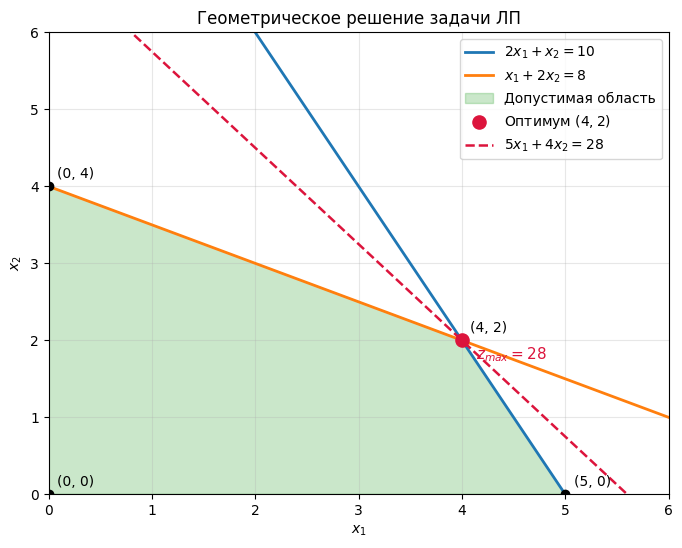

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Граничные прямые:
# 2*x1 + x2 = 10  -> x2 = 10 - 2*x1
# x1 + 2*x2 = 8   -> x2 = (8 - x1)/2
x1 = np.linspace(0, 6, 400)
line1 = 10 - 2 * x1
line2 = (8 - x1) / 2

# Вершины допустимой области
vertices = np.array([
    [0, 0],
    [5, 0],
    [4, 2],
    [0, 4],
], dtype=float)

# Оптимум из геометрического/программного решения
x_opt = np.array([4.0, 2.0])
z_opt = 5 * x_opt[0] + 4 * x_opt[1]  # 28

fig, ax = plt.subplots(figsize=(8, 6))

# Прямые ограничений
ax.plot(x1, line1, label=r'$2x_1 + x_2 = 10$', color='#1f77b4', linewidth=2)
ax.plot(x1, line2, label=r'$x_1 + 2x_2 = 8$', color='#ff7f0e', linewidth=2)

# Допустимая область
ax.fill(vertices[:, 0], vertices[:, 1], color='#2ca02c', alpha=0.25, label='Допустимая область')

# Вершины
ax.scatter(vertices[:, 0], vertices[:, 1], color='black', zorder=3)
for vx, vy in vertices:
    ax.annotate(f'({vx:.0f}, {vy:.0f})', (vx, vy), textcoords='offset points', xytext=(6, 6), fontsize=10)

# Оптимальная точка
ax.scatter(*x_opt, color='crimson', s=90, zorder=4, label=r'Оптимум $(4,2)$')
ax.annotate(r'$z_{\max}=28$', (x_opt[0], x_opt[1]), textcoords='offset points', xytext=(10, -14), color='crimson', fontsize=11)

# Линия уровня целевой функции через оптимум: 5*x1 + 4*x2 = 28
obj_line = (z_opt - 5 * x1) / 4
ax.plot(x1, obj_line, linestyle='--', color='crimson', linewidth=1.8, label=r'$5x_1 + 4x_2 = 28$')

# Оформление
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Геометрическое решение задачи ЛП')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.show()


## 6. Задание 2. Математическая запись, канонизация и решение в Python

### 6.1. Компактная математическая модель (та же самая задача)

$$
\max z = 5x_1 + 4x_2
$$

Здесь $x_1$ — объём выпуска A, $x_2$ — объём выпуска B, $z$ — прибыль.

$$
\begin{cases}
2x_1 + x_2 \le 10,\\
x_1 + 2x_2 \le 8,\\
x_1 \ge 0,\; x_2 \ge 0.
\end{cases}
$$

Здесь первые два неравенства — ресурсные ограничения, последние два — неотрицательность переменных.

### 6.2. Переход от максимизации к минимизации

`linprog` в базовой постановке решает задачу минимизации. Поэтому преобразуем цель:

$$
\max z = 5x_1 + 4x_2
$$

эквивалентно

$$
\min f = -5x_1 - 4x_2
$$

Почему это эквивалентно: если $z$ становится больше, то $-z$ становится меньше. Значит точка, где $z$ максимальна, одновременно делает $-z$ минимальным. После решения мы возвращаем исходную прибыль как $z_{\max} = -f_{\min}$.

### 6.3. Классический канонический вид с добавочными переменными

Для перехода от неравенств $\le$ к равенствам добавляем переменные запаса (добавочные переменные):

$$
2x_1 + x_2 + s_1 = 10
$$

$$
x_1 + 2x_2 + s_2 = 8
$$

$$
x_1,\; x_2,\; s_1,\; s_2 \ge 0
$$

Здесь $s_1$ и $s_2$ — добавочные переменные (slack variables). Они показывают, сколько ресурса осталось неиспользованным. Поэтому их называют добавочными: мы «добавляем» их к левой части, чтобы превратить неравенство в равенство.

### 6.4. Почему для SciPy удобен формат `A_ub`, `b_ub`, `bounds`

Хотя канонический вид через $s_1$, $s_2$ важен для понимания теории, библиотеке SciPy обычно удобнее дать исходные неравенства напрямую в матричном виде. Тогда `linprog` сама работает с внутренним представлением ограничений.

### 6.5. Векторно-матричная запись для Python

Вектор коэффициентов целевой функции (для минимизации отрицательной прибыли):

$$
c = \begin{pmatrix}
-5 \\
-4
\end{pmatrix}
$$

Здесь $c_1=-5$ соответствует переменной $x_1$; $c_2=-4$ соответствует переменной $x_2$.

Матрица ограничений:

$$
A_{ub} = \begin{pmatrix}2 & 1\\1 & 2\end{pmatrix}
$$

В формулах индекс пишем как $A_{ub}$ и $b_{ub}$, а в Python эти же объекты записываются как имена `A_ub` и `b_ub`.

Здесь первая строка $[2,1]$ — коэффициенты из ограничения $2x_1 + x_2 \le 10$; вторая строка $[1,2]$ — коэффициенты из ограничения $x_1 + 2x_2 \le 8$.

Вектор правых частей:

$$
b_{ub} = \begin{pmatrix}
10 \\
8
\end{pmatrix}
$$

Здесь $10$ — лимит первого ресурса, $8$ — лимит второго ресурса.

Ограничения на переменные:

$$
x_1 \ge 0,\quad x_2 \ge 0
$$

В SciPy это задаётся через `bounds = [(0, None), (0, None)]`, где $0$ — нижняя граница, `None` — отсутствие верхней границы.


In [2]:
import numpy as np
from scipy.optimize import linprog

# Вектор коэффициентов целевой функции для задачи МИНИМИЗАЦИИ.
# Мы минимизируем -5*x1 - 4*x2, что эквивалентно максимизации 5*x1 + 4*x2.
c = np.array([-5, -4], dtype=float)

# Матрица коэффициентов левой части неравенств A_ub @ x <= b_ub.
# Строка [2, 1] соответствует ограничению 2*x1 + 1*x2 <= 10.
# Строка [1, 2] соответствует ограничению 1*x1 + 2*x2 <= 8.
A_ub = np.array([
    [2, 1],
    [1, 2]
], dtype=float)

# Вектор правых частей ограничений.
b_ub = np.array([10, 8], dtype=float)

# Ограничения неотрицательности переменных:
# x1 >= 0 и x2 >= 0.
bounds = [(0, None), (0, None)]

# Решаем задачу методом HiGHS.
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

print("Успешность решения (res.success):", res.success)
print("Статус (res.status):", res.status)
print("Сообщение решателя (res.message):", res.message)

if res.success:
    x1, x2 = res.x
    f_min = res.fun         # Минимум функции f = -5*x1 - 4*x2
    z_max = -f_min          # Восстанавливаем максимум исходной прибыли

    print(f"Оптимальный план: x1 = {x1:.6g}, x2 = {x2:.6g}")
    print(f"Минимум f = {f_min:.6g}")
    print(f"Максимальная прибыль z_max = {z_max:.6g}")
else:
    print("Оптимальное решение не найдено.")


Успешность решения (res.success): True
Статус (res.status): 0
Сообщение решателя (res.message): Optimization terminated successfully. (HiGHS Status 7: Optimal)
Оптимальный план: x1 = 4, x2 = 2
Минимум f = -28
Максимальная прибыль z_max = 28


### 6.6. Как интерпретировать результаты Python

После успешного запуска (`res.success == True`) интерпретация такая:

1. `res.x` — найденный вектор решения.
- `res.x[0]` это $x_1$, то есть оптимальное количество изделий A.
- `res.x[1]` это $x_2$, то есть оптимальное количество изделий B.

2. `res.fun` — значение минимизируемой функции $f$.
- В нашей задаче $f = -5x_1 - 4x_2$.
- Поэтому `res.fun` получается отрицательным числом, равным $-z_{\max}$.

3. Восстановление максимальной прибыли:

$$
z_{\max} = -\,res.fun
$$

Здесь минус нужен потому, что мы решали не исходный максимум, а эквивалентный минимум отрицательной функции.

4. Экономическая интерпретация результата:
- оптимальный план обычно выходит $x_1 = 4$, $x_2 = 2$;
- соответствующая максимальная прибыль $z_{\max} = 28$ условных единиц.

Это полностью совпадает с ручным геометрическим решением, что служит взаимной проверкой двух подходов.


## 7. Типичные ошибки при выполнении работы

1. Неверное определение переменных (например, перепутаны $x_1$ и $x_2$).
2. Путаница между задачей максимума и задачей минимума.
3. Потеря условий неотрицательности $x_1 \ge 0$, $x_2 \ge 0$.
4. Неправильное построение полуплоскостей (выбрана не та сторона от прямой).
5. Ошибка при нахождении точки пересечения прямых (арифметическая или алгебраическая).
6. Ошибка при переходе от $\max$ к $\min$ (не поменяли знак целевой функции).
7. Путаница между классическим каноническим видом ($s_1$, $s_2$) и форматом входных данных SciPy (`A_ub`, `b_ub`, `bounds`).
8. Проверка целевой функции не во всех вершинах допустимой области.
9. Подстановка точки, не принадлежащей допустимой области.
10. Неверная экономическая интерпретация результата (например, трактовка `res.fun` как прибыли без смены знака).


## 8. Контрольные вопросы

1. Что такое линейное программирование и какие задачи оно решает?
2. Что в данной задаче означают переменные $x_1$ и $x_2$?
3. Почему целевая функция имеет вид $z = 5x_1 + 4x_2$?
4. Почему ресурсные ограничения записаны со знаком $\le$?
5. Зачем нужны условия неотрицательности переменных?
6. Что такое допустимая область и как она строится геометрически?
7. Почему в двумерной задаче оптимум ищется по вершинам допустимой области?
8. Как вручную найти точку пересечения прямых $2x_1 + x_2 = 10$ и $x_1 + 2x_2 = 8$?
9. Зачем при решении в SciPy выполнять переход от $\max$ к $\min$?
10. Что означают `A_ub`, `b_ub`, `bounds` в `linprog`?
11. Что означают `res.x`, `res.fun`, `res.success`?
12. Почему максимальную прибыль после минимизации отрицательной функции нужно восстанавливать сменой знака?
13. Что означает Лагранжев подход (ККТ) для задачи ЛП и как связаны множители с теневыми ценами?


## 9. Требования к отчёту

В отчёте обязательно должны быть:

1. Постановка задачи (словесно и математически).
2. Ручное геометрическое решение.
3. Рисунок допустимой области.
4. Вычисление всех угловых точек.
5. Проверка целевой функции во всех вершинах.
6. Канонизация задачи (включая $s_1$, $s_2$).
7. Матричная запись для Python ($c$, `A_ub`, `b_ub`, `bounds`).
8. Листинг программы на Python.
9. Скриншот результата выполнения программы.
10. Интерпретация найденного решения в экономических терминах.

## 10. Что должно быть в отчёте (чек-лист)

- [ ] Записаны переменные решения и их смысл.
- [ ] Записана целевая функция и расшифрованы коэффициенты.
- [ ] Записаны все ограничения и объяснён знак $\le$.
- [ ] Построены обе граничные прямые по двум опорным точкам.
- [ ] Выбраны правильные полуплоскости.
- [ ] Указаны все вершины допустимой области: $(0,0)$, $(5,0)$, $(4,2)$, $(0,4)$.
- [ ] Показано решение системы для точки пересечения прямых.
- [ ] Вычислены значения $z$ во всех вершинах: $0$, $25$, $28$, $16$.
- [ ] Сделан вывод: оптимум $x_1=4$, $x_2=2$, $z_{\max}=28$.
- [ ] Приведён и объяснён код Python с `linprog(method="highs")`.
- [ ] Пояснено восстановление прибыли по формуле $z_{\max} = -res.fun$.


## 11. Критерии оценивания

Рекомендуемая шкала: 100 баллов.

1. **Постановка модели (20 баллов)**
- корректно заданы переменные, цель, ограничения, неотрицательность;
- есть понятная расшифровка всех обозначений.

2. **Геометрическое решение (30 баллов)**
- корректно построены прямые и полуплоскости;
- верно выделена допустимая область;
- корректно найдены вершины;
- правильно вычислены значения целевой функции в вершинах и выбран максимум.

3. **Канонизация и матричная форма (20 баллов)**
- корректный переход к виду с $s_1$, $s_2$;
- корректная запись $c$, `A_ub`, `b_ub`, `bounds`.

4. **Программная реализация в Python (20 баллов)**
- код запускается;
- используется `linprog(..., method="highs")`;
- корректная интерпретация `res.x`, `res.fun`, `res.success`;
- корректно восстановлена максимальная прибыль сменой знака.

5. **Оформление и выводы (10 баллов)**
- отчёт структурирован;
- присутствуют рисунок, скриншот и экономическая интерпретация;
- выводы согласованы с вычислениями.

## 12. Минимальный шаблон вывода по лабораторной работе

Используйте этот шаблон в конце отчёта:

> **Вывод:**
> В лабораторной работе №1 была построена математическая модель задачи линейного программирования для двух видов продукции. Задача решена двумя способами: геометрически и программно в Python через `scipy.optimize.linprog` (`method="highs"`).
> По геометрическому методу найдены вершины допустимой области $(0,0)$, $(5,0)$, $(4,2)$, $(0,4)$, вычислены значения целевой функции $0$, $25$, $28$, $16$.
> Максимальная прибыль достигается в точке $x_1=4$, $x_2=2$ и равна $z_{\max}=28$ условных единиц.
> Результат Python-решения совпал с ручным решением, что подтверждает корректность модели и вычислений.
